# 02. Populations, Units, Variables, and Data-Generating Processes

A statistical analysis can look mathematically polished and still answer the wrong question. The most common reason is that the underlying objects of analysis were never defined carefully. What is the population? What counts as a unit? Which variable is an outcome, which variable is context, and which variable is only an imperfect proxy? What process generated the observed rows in the first place?

We stay with the same synthetic marketplace support setting from Notebook 01. The operational team wants to evaluate service reliability for seller support, but before we summarize or model anything, we need to understand what the data actually represent. That is the lecture’s central message: statistical clarity begins before estimation.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Distinguish a target population from a frame population and from an observed sample.
2. Explain why rows in a table are not automatically the right statistical units.
3. Classify variables by role and measurement scale in a decision-oriented dataset.
4. Show how operational definitions of outcomes can materially change a business conclusion.
5. Describe a data-generating process as the source of both useful signal and systematic bias.
6. Diagnose how logging systems and observation rules can distort what an analyst sees.
7. Translate these object-definition choices into a more defensible analytical recommendation.


In [11]:
# Load the libraries and notebook settings used in the examples below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 24)

from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display

## 1. Statistical Analysis Starts by Defining the Objects

Before computing a mean, we need to know what the mean is averaging. Before reporting a rate, we need to know what is in the numerator and denominator. Before trusting a dashboard, we need to know which events make it into that dashboard and which do not.

For a marketplace support workflow, even a simple operational question can fragment into several different statistical questions:

- Are we describing all tickets or only tickets that were successfully logged in a reporting system?
- Are we averaging over tickets, sellers, seller-days, or support queues?
- Are we evaluating first-response speed, full-resolution speed, breach risk, or cost?
- Are repeated tickets from the same seller being allowed to dominate the summary?

Those are not cosmetic choices. They determine the quantity being estimated.


| Object | Practical Definition | Why It Matters |
|---|---|---|
| Target population | All seller-support tickets the firm may need to serve next quarter | This is the population the decision should ideally be about |
| Frame population | Tickets that actually appear in the dashboard or logging pipeline | This is often what the analyst really has access to |
| Sample | A finite subset of rows reviewed or exported for analysis | Estimates vary because samples are incomplete |
| Unit of analysis | The object being averaged or compared, such as a ticket or a seller | The same dataset can imply different answers under different units |
| Outcome | The quantity used for judgment, such as first-response time or resolution time | Different outcome definitions can reverse apparent performance |
| Covariates | Context variables such as severity, channel, region, or queue load | These help explain structure and reveal when averages are mixtures |
| Data-generating process | The operational mechanism that creates the observed rows | It is the source of both genuine signal and systematic distortion |


This table may look basic, but it is where serious analysis begins. Many downstream errors can be traced to treating these definitions as obvious when they are not.

A row in a dataset is only a row. It becomes a statistical unit after we decide what it stands for. A dashboard is only a view of a process. It becomes an empirical frame after we understand how events enter or fail to enter it. A metric is only a number. It becomes evidence after we define what operational reality it is supposed to measure.

In decision science, careful definitions are not clerical overhead. They are part of the inferential work.

## 2. Simulating a Support Operation With Structure

To study these ideas cleanly, we simulate a full operational system. We start with sellers, then generate tickets from sellers, and then generate response and resolution outcomes from the workflow conditions attached to those tickets.

### Dataset and Experiment Design

Each seller has a tier, region, expected support demand, and service context. Tickets are then generated from that seller population. Each ticket row records the seller that produced it, the channel through which it arrived, its severity, the queue pressure at arrival, the assigned analyst experience, and the resulting response and resolution outcomes.

The experiment is about changing the object of analysis. Sometimes the right unit is a seller, sometimes a ticket, sometimes a seller-week, and sometimes a dashboard export. By creating all of these objects from the same underlying operation, the notebook shows why population, frame, unit, row, and variable definitions are not paperwork. They determine what question the analysis can answer.

This means the observed rows are not independent points floating in space. They are descendants of sellers, workload pressure, severity, intake channel, staffing conditions, and random noise. That is what a data-generating process means in practice.

In [12]:
# Define helper functions and reusable utilities for this section.
rng = np.random.default_rng(2031)

def sigmoid(x):
    """
    Transform a linear score into a probability with the logistic function.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        A scalar or NumPy array containing the logistic transform of `x`, useful for converting linear scores into probabilities.
    
    Idea:
        Convert additive risk drivers into bounded probabilities, allowing synthetic event rates to respond smoothly to covariates.
    """
    return 1.0 / (1.0 + np.exp(-x))


n_sellers = 2800
seller_tier_levels = np.array(["standard", "growth", "enterprise"])
region_levels = np.array(["North", "South", "West", "Central"])
severity_levels = ["low", "medium", "high", "urgent"]
channel_levels = np.array(["chat", "email", "phone"])

seller_tier = rng.choice(seller_tier_levels, size=n_sellers, p=[0.62, 0.25, 0.13])
region = rng.choice(region_levels, size=n_sellers, p=[0.27, 0.24, 0.28, 0.21])
account_age_months = rng.integers(4, 121, size=n_sellers)
priority_contract = (
    (seller_tier == "enterprise")
    | ((seller_tier == "growth") & (rng.random(n_sellers) < 0.35))
).astype(int)

tier_complexity_shift = {"standard": -0.18, "growth": 0.04, "enterprise": 0.26}
region_complexity_shift = {"North": -0.06, "South": 0.04, "West": 0.14, "Central": 0.00}

latent_complexity = rng.normal(
    loc=np.vectorize(tier_complexity_shift.get)(seller_tier)
    + np.vectorize(region_complexity_shift.get)(region),
    scale=0.75,
    size=n_sellers,
)

ticket_rate = np.exp(
    0.75
    + 0.18 * (seller_tier == "growth")
    + 0.40 * (seller_tier == "enterprise")
    + 0.30 * priority_contract
    + 0.22 * latent_complexity
)
n_tickets = np.maximum(1, rng.poisson(ticket_rate)).astype(int)

sellers = pd.DataFrame(
    {
        "seller_id": np.arange(1, n_sellers + 1),
        "seller_tier": seller_tier,
        "region": region,
        "account_age_months": account_age_months,
        "priority_contract": priority_contract,
        "latent_complexity": latent_complexity,
        "n_tickets": n_tickets,
    }
)

population = sellers.loc[sellers.index.repeat(sellers["n_tickets"])].copy().reset_index(drop=True)
population["ticket_id"] = np.arange(1, len(population) + 1)

severity_score = (
    population["latent_complexity"].to_numpy()
    + 0.22 * population["priority_contract"].to_numpy()
    + rng.normal(0, 0.90, size=len(population))
)
population["severity"] = pd.cut(
    severity_score,
    bins=[-np.inf, -0.55, 0.35, 1.10, np.inf],
    labels=severity_levels,
)
population["severity"] = pd.Categorical(population["severity"], categories=severity_levels, ordered=True)

channel_probability_map = {
    "low": [0.63, 0.28, 0.09],
    "medium": [0.45, 0.35, 0.20],
    "high": [0.24, 0.39, 0.37],
    "urgent": [0.09, 0.33, 0.58],
}

channel = np.empty(len(population), dtype=object)
for sev, probs in channel_probability_map.items():
    mask = population["severity"] == sev
    channel[mask] = rng.choice(channel_levels, size=mask.sum(), p=probs)
population["channel"] = channel

overnight_prob = sigmoid(
    -1.95
    + 0.62 * (population["severity"] == "urgent").astype(float).to_numpy()
    + 0.34 * (population["region"] == "West").astype(float).to_numpy()
    + 0.20 * (population["channel"] == "phone").astype(float).to_numpy()
)
population["overnight"] = rng.binomial(1, overnight_prob)

business_hours = np.arange(7, 22)
overnight_hours = np.array([0, 1, 2, 3, 4, 5, 6, 22, 23])
created_hour = np.empty(len(population), dtype=int)
overnight_mask = population["overnight"].to_numpy().astype(bool)
created_hour[overnight_mask] = rng.choice(overnight_hours, size=overnight_mask.sum())
created_hour[~overnight_mask] = rng.choice(business_hours, size=(~overnight_mask).sum())
population["created_hour"] = created_hour

region_load_shift = {"North": -0.12, "South": 0.03, "West": 0.18, "Central": 0.00}
severity_load_shift = {"low": -0.18, "medium": 0.05, "high": 0.36, "urgent": 0.72}

queue_load = rng.normal(
    loc=population["region"].map(region_load_shift).to_numpy()
    + population["severity"].map(severity_load_shift).to_numpy()
    + 0.65 * population["overnight"].to_numpy(),
    scale=0.70,
    size=len(population),
)
population["queue_load"] = np.clip(queue_load, -2.2, 3.4)

region_experience_shift = {"North": 0.10, "South": 0.02, "West": -0.08, "Central": 0.05}
analyst_experience = rng.normal(
    loc=0.25
    + population["region"].map(region_experience_shift).to_numpy()
    - 0.18 * population["queue_load"].to_numpy()
    - 0.12 * (population["severity"] == "urgent").astype(float).to_numpy(),
    scale=0.85,
    size=len(population),
)
population["analyst_experience"] = np.clip(analyst_experience, -2.5, 2.5)

first_response_log = (
    2.05
    + population["severity"].map({"low": -0.25, "medium": 0.00, "high": 0.45, "urgent": 0.78}).to_numpy()
    + 0.28 * population["queue_load"].to_numpy()
    + 0.22 * population["overnight"].to_numpy()
    + 0.10 * (population["channel"] == "phone").astype(float).to_numpy()
    - 0.12 * population["analyst_experience"].to_numpy()
    + rng.normal(0, 0.35, size=len(population))
)
population["first_response_minutes"] = np.exp(first_response_log)

additional_work_log = (
    2.70
    + population["severity"].map({"low": -0.20, "medium": 0.12, "high": 0.52, "urgent": 0.90}).to_numpy()
    + 0.25 * population["queue_load"].to_numpy()
    + 0.24 * population["latent_complexity"].to_numpy()
    - 0.08 * population["analyst_experience"].to_numpy()
    + 0.12 * (population["channel"] == "phone").astype(float).to_numpy()
    + rng.normal(0, 0.40, size=len(population))
)
population["resolution_minutes"] = population["first_response_minutes"] + np.exp(additional_work_log)

population["response_sla_breach"] = (population["first_response_minutes"] > 15).astype(int)
population["resolution_sla_breach"] = (population["resolution_minutes"] > 90).astype(int)

cost_per_ticket = (
    16
    + 0.09 * population["resolution_minutes"].to_numpy()
    + 5.0 * (population["channel"] == "phone").astype(float).to_numpy()
    + 4.0 * (population["severity"] == "urgent").astype(float).to_numpy()
    + rng.normal(0, 2.20, size=len(population))
)
population["cost_per_ticket"] = np.clip(cost_per_ticket, 6, None)

dashboard_logit = (
    2.10
    - 1.55 * (population["channel"] == "phone").astype(float).to_numpy()
    - 1.05 * population["overnight"].to_numpy()
    - 0.75 * (population["severity"] == "urgent").astype(float).to_numpy()
    + 0.30 * population["priority_contract"].to_numpy()
)
population["dashboard_logged"] = rng.binomial(1, sigmoid(dashboard_logit))

population_overview = pd.DataFrame(
    [
        {"quantity": "Sellers in simulated population", "value": len(sellers)},
        {"quantity": "Tickets in simulated population", "value": len(population)},
        {"quantity": "Mean tickets per seller", "value": population.groupby("seller_id", observed=True).size().mean()},
        {"quantity": "Share of priority-contract sellers", "value": sellers["priority_contract"].mean()},
        {"quantity": "Share of tickets visible in dashboard", "value": population["dashboard_logged"].mean()},
    ]
)

smart_display(population_overview)

,quantity,value
0,Sellers in simulated population,2800.000000
1,Tickets in simulated population,7758.000000
2,Mean tickets per seller,2.770714
3,Share of priority-contract sellers,0.226429
4,Share of tickets visible in dashboard,0.763986


This synthetic operation is intentionally controlled, but it is not meant to be frictionless. The data include uneven ticket volume, channel-dependent logging, severity mix, queue congestion, staff experience, and noisy outcomes. That structure lets us see how the object of analysis changes before we move to fully real operational data later in the lecture.


## Variable Guide

| Variable | Statistical Role | Measurement Scale | Why It Matters |
|---|---|---|---|
| `seller_tier` | Segment descriptor | Nominal categorical | Different seller segments produce different case profiles and service expectations |
| `priority_contract` | Eligibility flag | Binary | Distinguishes sellers eligible for a higher service standard |
| `severity` | Difficulty indicator | Ordinal categorical | Encodes escalating operational complexity |
| `channel` | Intake mode | Nominal categorical | Phone, email, and chat behave differently in service operations |
| `queue_load` | System-state covariate | Continuous index | Captures real-time congestion and resource pressure |
| `analyst_experience` | Workforce capability covariate | Continuous score | More experienced staff tend to resolve cases faster |
| `first_response_minutes` | Early-service outcome | Positive continuous | Measures how quickly a seller hears back |
| `resolution_minutes` | End-to-end outcome | Positive continuous | Measures full completion time, including more than initial contact |
| `response_sla_breach` | Operational failure indicator | Binary | Summarizes risk relative to a response-time promise |
| `dashboard_logged` | Observation mechanism | Binary | Determines whether the analyst even gets to see the ticket |


There are two distinct ideas here.

First, variables play different roles. Some are outcomes, some are system descriptors, and some describe the observation process itself. In practice, `dashboard_logged` is every bit as important as a business metric, because it determines what evidence enters the analyst's field of view.

Second, measurement scale matters. A nominal variable such as `channel` should be handled as categories. An ordinal variable such as `severity` contains order without necessarily having equal spacing. Binary outcomes are often convenient for decision thresholds, but they compress information and can hide how close misses are to the threshold.

Once those distinctions are explicit, later notebooks on probability, estimation, and modeling become much easier to interpret correctly.

## 3. Target Population, Frame Population, and Observed Sample

The target population is what the decision should be about. The frame population is what the data system exposes. The sample is what the analyst actually pulls for review.

These can differ sharply. In many organizations, urgent phone cases created overnight are exactly the cases most likely to be partially logged, delayed, or excluded from routine dashboard views. That means the most operationally consequential cases can be the least statistically visible.


In [13]:
# Define helper functions and reusable utilities for this section.
dashboard_frame = population.loc[population["dashboard_logged"] == 1].copy()
audit_sample = population.sample(n=1800, random_state=2026)
dashboard_sample = dashboard_frame.sample(n=min(1800, len(dashboard_frame)), random_state=2027)

def summarize_view(df, label):
    """
    Summarize view into a compact table or record.
    
    Parameters:
        df: Input DataFrame used by the summary, model, or display helper.
        label: Human-readable label attached to the returned summary.
    
    Returns:
        A dictionary describing the selected analysis view, including coverage, unit counts, and operational composition.
    
    Idea:
        Compare different views of the same operation to show how population, frame, and observed sample can answer different questions.
    """
    return {
        "view": label,
        "tickets": len(df),
        "sellers": df["seller_id"].nunique(),
        "coverage_vs_population": len(df) / len(population),
        "share_urgent": (df["severity"] == "urgent").mean(),
        "share_phone": (df["channel"] == "phone").mean(),
        "share_overnight": df["overnight"].mean(),
        "mean_first_response_minutes": df["first_response_minutes"].mean(),
        "mean_resolution_minutes": df["resolution_minutes"].mean(),
        "response_breach_rate": df["response_sla_breach"].mean(),
    }


view_summary = pd.DataFrame(
    [
        summarize_view(population, "Target population: all tickets"),
        summarize_view(dashboard_frame, "Frame population: dashboard-visible tickets"),
        summarize_view(audit_sample, "Observed sample: random audit from all tickets"),
        summarize_view(dashboard_sample, "Observed sample: dashboard export"),
    ]
).set_index("view")

smart_display(view_summary)

,tickets,sellers,coverage_vs_population,share_urgent,share_phone,share_overnight,mean_first_response_minutes,mean_resolution_minutes,response_breach_rate
view,,,,,,,,,
Target population: all tickets,7758,2800,1.000,0.230,0.294,0.163,14.330,46.284,0.340
Frame population: dashboard-visible tickets,5927,2583,0.764,0.170,0.204,0.121,12.804,41.093,0.283
Observed sample: random audit from all tickets,1800,1344,0.232,0.218,0.294,0.171,14.013,44.877,0.327
Observed sample: dashboard export,1800,1359,0.232,0.170,0.212,0.128,12.885,40.676,0.284


This comparison separates the population we care about from the frame we can actually observe. That distinction matters because a clean calculation on the wrong frame can still support the wrong decision.


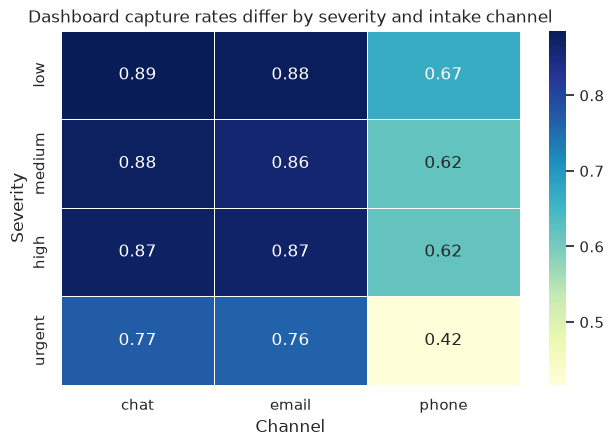

In [14]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
capture_heatmap = (
    population.groupby(["severity", "channel"], observed=True)["dashboard_logged"]
    .mean()
    .unstack()
    .reindex(index=severity_levels)
)

plt.figure(figsize=(7.4, 4.6))
sns.heatmap(capture_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Dashboard capture rates differ by severity and intake channel")
plt.xlabel("Channel")
plt.ylabel("Severity")
plt.show()


The summary table and heatmap work best together.

The table compares four views of ostensibly the same operation, but they are not equivalent. The dashboard-visible frame can have lower urgent-case share, lower phone share, lower overnight share, and faster average service simply because the logging mechanism favors easier-to-observe work.

The heatmap makes the mechanism concrete. Capture rates are not uniform. Some types of tickets are more likely to enter the analyst's frame than others. That means dashboard-based statistics can be directionally misleading even before we worry about sampling variability.

This is one of the deepest habits in applied statistics: always ask how the observed rows were admitted into view.

## 4. Units Are Not the Same Thing as Rows

Suppose the table contains one row per ticket. That does **not** force the analysis to be ticket-level. A seller who generates many tickets will appear many times and therefore receive more statistical weight in a row-weighted summary.

If the quantity of interest is average service per ticket, row-weighting may be appropriate. If the quantity of interest is average service experience per seller, then repeated tickets from the same seller should usually be collapsed before averaging.

Formally, these are different estimands:

$$
\theta_{\text{ticket}} = \frac{1}{N_{\text{ticket}}} \sum_{j=1}^{N_{\text{ticket}}} Y_j
$$

and

$$
\theta_{\text{seller}} = \frac{1}{N_{\text{seller}}} \sum_{s=1}^{N_{\text{seller}}} \bar{Y}_s
$$

where $\bar{Y}_s$ is the seller-level average over that seller's tickets.


In [15]:
# Build a summary table that supports the interpretation in the surrounding notes.
seller_level = (
    population.groupby("seller_id", observed=True)
    .agg(
        tickets=("ticket_id", "size"),
        mean_first_response_minutes=("first_response_minutes", "mean"),
        mean_resolution_minutes=("resolution_minutes", "mean"),
        response_breach_rate=("response_sla_breach", "mean"),
        any_response_breach=("response_sla_breach", "max"),
    )
)

unit_comparison = pd.DataFrame(
    [
        {
            "quantity": "Ticket-weighted mean first response",
            "value": population["first_response_minutes"].mean(),
        },
        {
            "quantity": "Seller-weighted mean of seller first-response averages",
            "value": seller_level["mean_first_response_minutes"].mean(),
        },
        {
            "quantity": "Ticket-weighted response breach rate",
            "value": population["response_sla_breach"].mean(),
        },
        {
            "quantity": "Share of sellers with at least one response breach",
            "value": seller_level["any_response_breach"].mean(),
        },
        {
            "quantity": "Average number of tickets per seller",
            "value": seller_level["tickets"].mean(),
        },
    ]
)

smart_display(unit_comparison)


,quantity,value
0,Ticket-weighted mean first response,14.330108
1,Seller-weighted mean of seller first-response averages,13.238404
2,Ticket-weighted response breach rate,0.340165
3,Share of sellers with at least one response breach,0.498571
4,Average number of tickets per seller,2.770714


The aggregation changes the unit of analysis, and therefore changes the question being answered. Rows, customers, tickets, teams, and time periods can all imply different denominators and different decisions.


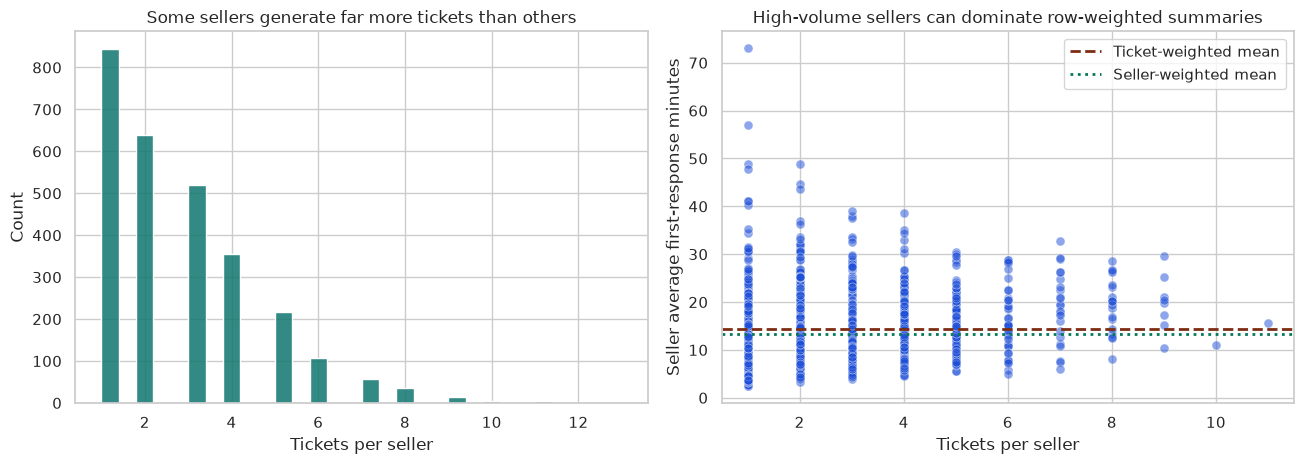

In [16]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
seller_plot_sample = seller_level.sample(n=min(1200, len(seller_level)), random_state=2042)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

sns.histplot(seller_level["tickets"], bins=30, color="#0f766e", alpha=0.85, ax=axes[0])
axes[0].set_title("Some sellers generate far more tickets than others")
axes[0].set_xlabel("Tickets per seller")

sns.scatterplot(
    data=seller_plot_sample,
    x="tickets",
    y="mean_first_response_minutes",
    alpha=0.50,
    s=42,
    color="#1d4ed8",
    ax=axes[1],
)
axes[1].axhline(
    population["first_response_minutes"].mean(),
    color="#7c2d12",
    linestyle="--",
    linewidth=2,
    label="Ticket-weighted mean",
)
axes[1].axhline(
    seller_level["mean_first_response_minutes"].mean(),
    color="#047857",
    linestyle=":",
    linewidth=2,
    label="Seller-weighted mean",
)
axes[1].set_title("High-volume sellers can dominate row-weighted summaries")
axes[1].set_xlabel("Tickets per seller")
axes[1].set_ylabel("Seller average first-response minutes")
axes[1].legend()

plt.tight_layout()
plt.show()


The first panel shows why rows are not neutral. Some sellers generate a great deal more traffic than others. If we average over tickets, those sellers get more weight by construction. Sometimes that is exactly what we want, because each ticket is a unit of workload. Sometimes the practical question is about typical seller experience, which makes the seller the right unit.

The second panel makes the point operational. The ticket-weighted and seller-weighted means are both mathematically valid, but they answer different questions. Likewise, the ticket-level breach rate is not the same thing as the share of sellers who experienced at least one breach.

When analysts say "the average" without specifying the unit, they are often hiding the central design choice of the analysis.

## 5. Variable Roles, Measurement Scales, and Operational Definitions

A dataset can be statistically well formed and still operationally ambiguous. The ambiguity often shows up in the outcome definition.

For example, two teams may each report that "support performance is improving" while one is using first-response time and the other is using full-resolution time. These are related but distinct outcomes. The first captures how quickly a seller is acknowledged. The second captures how quickly the underlying issue is truly resolved.


| Variable | Scale | Typical Mistake | Better Interpretation |
|---|---|---|---|
| `seller_tier` | Nominal | Treating labels as if they are numeric distances | Use as a grouping or segmentation variable |
| `severity` | Ordinal | Assuming the gap from low to medium equals the gap from high to urgent | Respect order, but be cautious about linear spacing assumptions |
| `created_hour` | Cyclical discrete | Treating hour 23 as far from hour 0 | Remember clock time wraps around |
| `queue_load` | Continuous index | Treating it as directly interpretable in business units | Use it as a latent state or relative congestion measure |
| `first_response_minutes` | Continuous positive | Confusing acknowledgement speed with complete service quality | Good for responsiveness, incomplete for total completion |
| `resolution_minutes` | Continuous positive | Using it as the only service metric | Good for end-to-end completion, but less specific about responsiveness |
| `response_sla_breach` | Binary | Forgetting that thresholding discards near-threshold detail | Good for operational policy, but coarser than raw times |


In [17]:
# Build a summary table that supports the interpretation in the surrounding notes.
region_metric_table = (
    population.groupby("region", observed=True)
    .agg(
        mean_first_response_minutes=("first_response_minutes", "mean"),
        mean_resolution_minutes=("resolution_minutes", "mean"),
        response_breach_rate=("response_sla_breach", "mean"),
        resolution_breach_rate=("resolution_sla_breach", "mean"),
        urgent_share=("severity", lambda s: (s == "urgent").mean()),
        phone_share=("channel", lambda s: (s == "phone").mean()),
    )
)

region_metric_table["rank_by_first_response"] = (
    region_metric_table["mean_first_response_minutes"].rank(method="dense").astype(int)
)
region_metric_table["rank_by_resolution"] = (
    region_metric_table["mean_resolution_minutes"].rank(method="dense").astype(int)
)

region_metric_table.sort_values("rank_by_first_response")


,mean_first_response_minutes,mean_resolution_minutes,response_breach_rate,resolution_breach_rate,urgent_share,phone_share,rank_by_first_response,rank_by_resolution
region,,,,,,,,
North,12.659,40.463,0.281,0.086,0.192,0.268,1,1
Central,13.961,45.068,0.325,0.099,0.220,0.291,2,2
South,14.171,45.482,0.329,0.122,0.233,0.290,3,3
West,16.431,53.767,0.421,0.163,0.271,0.324,4,4


The region table highlights an underappreciated lesson: a ranking depends on the outcome definition. One region can look relatively strong on first response and weaker on full resolution if it acknowledges cases quickly but struggles to complete harder work. Another can look weaker on responsiveness but stronger on completion discipline.

This is why "what is the outcome?" should be asked with the same seriousness as "what is the estimate?" Analysts often talk as if metrics are interchangeable views of the same reality. They are not. They are different operational lenses.

At this stage of the course, the goal is not to pick a universal best metric. The goal is to become explicit about what each metric actually measures.

## 6. The Data-Generating Process Creates Structure

A data-generating process is the mechanism that turns real-world conditions into observed values. In our synthetic support system, response and resolution times are not random in a featureless sense. They are generated by seller complexity, case severity, intake channel, queue congestion, staff experience, and noise.

We can summarize that idea abstractly as

$$
Y = g(\text{severity},\ \text{channel},\ \text{queue load},\ \text{seller complexity},\ \text{staff experience},\ \varepsilon)
$$

where $\varepsilon$ represents the irreducible randomness and unmeasured detail that remain even after the main drivers are accounted for.


queue_band,light,normal,congested
severity,,,
low,14.328,18.565,24.521
medium,21.363,27.774,35.642
high,36.318,44.545,60.531
urgent,55.746,74.537,105.532


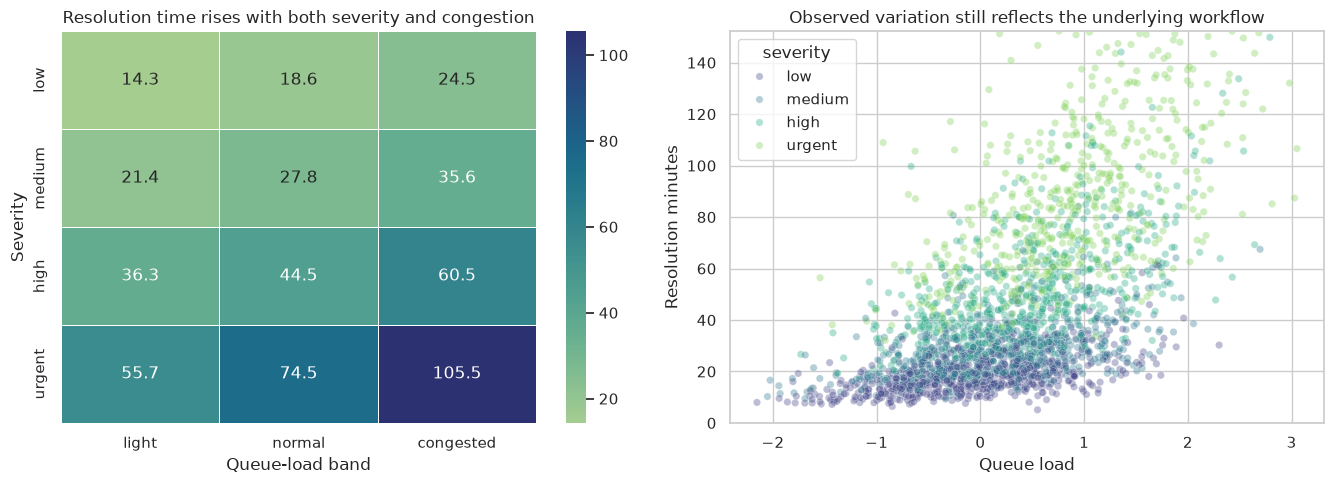

In [18]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
population["queue_band"] = pd.cut(
    population["queue_load"],
    bins=[-np.inf, -0.4, 0.5, np.inf],
    labels=["light", "normal", "congested"],
)

dgp_heatmap = (
    population.groupby(["severity", "queue_band"], observed=True)["resolution_minutes"]
    .mean()
    .unstack()
    .reindex(index=severity_levels)
)
smart_display(dgp_heatmap)

plot_sample = population.sample(n=min(2500, len(population)), random_state=2050)
upper_limit = population["resolution_minutes"].quantile(0.98)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

sns.heatmap(dgp_heatmap, annot=True, fmt=".1f", cmap="crest", linewidths=0.5, ax=axes[0])
axes[0].set_title("Resolution time rises with both severity and congestion")
axes[0].set_xlabel("Queue-load band")
axes[0].set_ylabel("Severity")

sns.scatterplot(
    data=plot_sample,
    x="queue_load",
    y="resolution_minutes",
    hue="severity",
    alpha=0.35,
    s=28,
    palette="viridis",
    ax=axes[1],
)
axes[1].set_ylim(0, upper_limit)
axes[1].set_title("Observed variation still reflects the underlying workflow")
axes[1].set_xlabel("Queue load")
axes[1].set_ylabel("Resolution minutes")

plt.tight_layout()
plt.show()


The heatmap and scatter plot show the structural nature of the data. Congested queues are slower. Harder tickets are slower. Urgent work in congested conditions is slowest of all. That may sound obvious. Statistical practice improves when the obvious is written down as part of the data story.

This also reveals why descriptive averages can mislead. If one region receives a heavier mix of urgent, phone-based, overnight work, then its raw averages inherit those conditions. The numbers are not wrong. They are generated by a system with composition, dependence, and workflow heterogeneity.

Later in the course, this perspective will connect naturally to probability models, regression, and causal adjustment. For now, the main point is simpler: data are outputs of processes, not isolated facts.

## 7. A Recommendation Can Change When the Object Changes

Suppose leadership is considering a premium promise that requires average first response to be comfortably below a target. Even before we get to formal uncertainty quantification, the apparent readiness can change depending on whether we define the analysis over all tickets, the dashboard frame, a seller-weighted unit, or a different segment population.

This is why object-definition mistakes are dangerous. They can move the recommendation itself. They can move the recommendation itself.


In [19]:
# Build a summary table that supports the interpretation in the surrounding notes.
response_views = pd.DataFrame(
    [
        {
            "view": "All tickets in target population",
            "estimate_minutes": population["first_response_minutes"].mean(),
        },
        {
            "view": "Dashboard-visible frame only",
            "estimate_minutes": dashboard_frame["first_response_minutes"].mean(),
        },
        {
            "view": "Random audit sample from all tickets",
            "estimate_minutes": audit_sample["first_response_minutes"].mean(),
        },
        {
            "view": "Seller-weighted mean of seller averages",
            "estimate_minutes": seller_level["mean_first_response_minutes"].mean(),
        },
        {
            "view": "Priority-contract seller tickets only",
            "estimate_minutes": population.loc[
                population["priority_contract"] == 1, "first_response_minutes"
            ].mean(),
        },
    ]
)

for threshold in [14, 16, 18]:
    response_views[f"meets_{threshold}min_target"] = np.where(
        response_views["estimate_minutes"] <= threshold,
        "Yes",
        "No",
    )

response_views.sort_values("estimate_minutes")


,view,estimate_minutes,meets_14min_target,meets_16min_target,meets_18min_target
1,Dashboard-visible frame only,12.804,Yes,Yes,Yes
3,Seller-weighted mean of seller averages,13.238,Yes,Yes,Yes
2,Random audit sample from all tickets,14.013,No,Yes,Yes
0,All tickets in target population,14.330,No,Yes,Yes
4,Priority-contract seller tickets only,16.564,No,No,Yes


This table shows how a recommendation can look more or less favorable depending on what was averaged.

A dashboard-only view may suggest stronger readiness than the full target population if harder cases are under-captured. A seller-weighted summary may differ from a ticket-weighted summary if a small set of heavy-volume sellers dominate the row count. A priority-contract population can differ from the overall ticket population because it serves a different mix of cases.

So when a stakeholder asks, "Are we ready?" the first professional response should often be, "Ready according to which population, which unit, and which outcome definition?"

## 8. Real-Data Companion: NYC 311 and the Unit of Analysis

The synthetic support system gave us a controlled way to separate target populations, frame populations, rows, units, and variables. NYC 311 is a useful reality check because the same distinction appears in a public operational dataset. The data come from service requests submitted to New York City agencies. A row is a request, with fields such as creation date, close date, agency, complaint type, borough, ZIP code, channel, and status.

The important teaching point is that a row is not automatically the right unit for every question. A 311 analysis might use the request as the unit when studying resolution time, the complaint type as the unit when comparing service categories, the borough or ZIP code as the unit when studying geography, or the agency as the unit when studying operational responsibility. Each choice changes the denominator and the question being answered.

The companion below pulls or uses a cached small sample from the official NYC Open Data API and compares summaries by row, complaint type, and borough. This is not a final city-performance evaluation. It is a unit-of-analysis exercise: before estimating anything, the analyst must decide what entity the estimate is about and whether the available data support that target.

For clarity, the unit changes across the companion: sometimes a service request, sometimes a complaint type, sometimes a borough. There is no single fixed outcome; the experiment is to show how counts, resolution summaries, and composition summaries change when the unit of analysis changes.

Data source: [NYC Open Data 311 Service Requests](https://data.cityofnewyork.us/api/views/erm2-nwe9).

,analysis_object,quantity,value,interpretation
0,Service-request rows,Median resolution hours,1.040000,Workload-weighted view. High-volume complaint types receive more influence.
1,Complaint types,Median of complaint-type medians,1.390000,Problem-weighted view. Rare complaint types count as objects too.
2,Boroughs,Median of borough medians,1.120000,Geographic view. Borough composition and volume no longer dominate by default.


,borough,requests,median_hours,p90_hours
0,QUEENS,1466,1.110,6.280
1,BRONX,902,1.060,4.430
2,BROOKLYN,1562,1.150,4.380
3,STATEN ISLAND,136,1.130,4.320
4,Unspecified,3,3.680,4.280
5,MANHATTAN,928,0.830,3.840


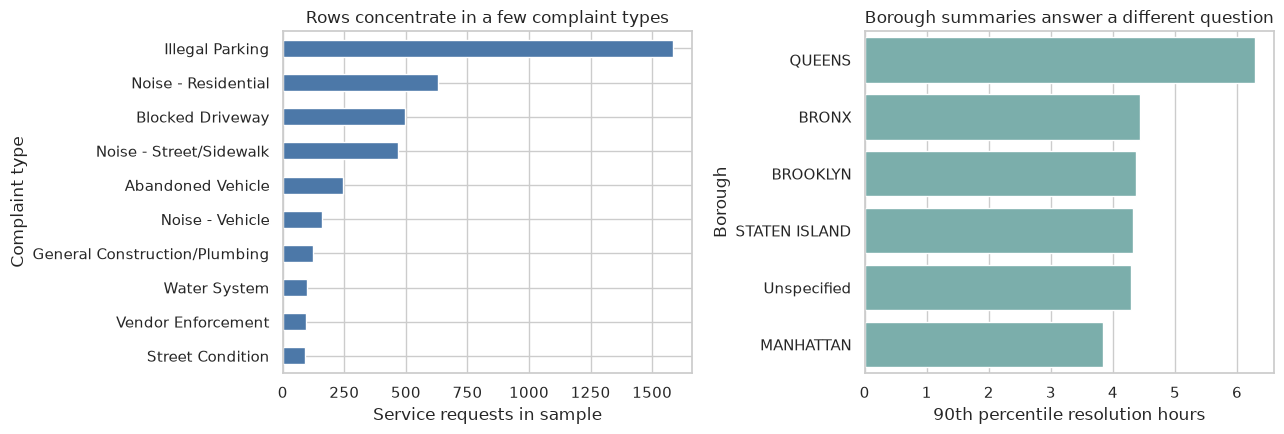

In [20]:
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import fetch_nyc_311, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    nyc_311 = fetch_nyc_311(limit=5_000, start_date="2025-01-01")
    nyc_311["resolution_hours"] = (
        nyc_311["closed_date"] - nyc_311["created_date"]
    ).dt.total_seconds() / 3600
    nyc_311 = nyc_311.query("0 <= resolution_hours <= 720").copy()

    row_summary = pd.DataFrame(
        [
            {
                "analysis_object": "Service-request rows",
                "quantity": "Median resolution hours",
                "value": nyc_311["resolution_hours"].median(),
                "interpretation": "Workload-weighted view. High-volume complaint types receive more influence.",
            },
            {
                "analysis_object": "Complaint types",
                "quantity": "Median of complaint-type medians",
                "value": nyc_311.groupby("complaint_type")["resolution_hours"].median().median(),
                "interpretation": "Problem-weighted view. Rare complaint types count as objects too.",
            },
            {
                "analysis_object": "Boroughs",
                "quantity": "Median of borough medians",
                "value": nyc_311.groupby("borough")["resolution_hours"].median().median(),
                "interpretation": "Geographic view. Borough composition and volume no longer dominate by default.",
            },
        ]
    )

    borough_summary = (
        nyc_311.groupby("borough", dropna=False)
        .agg(
            requests=("unique_key", "count"),
            median_hours=("resolution_hours", "median"),
            p90_hours=("resolution_hours", lambda s: s.quantile(0.90)),
        )
        .sort_values("p90_hours", ascending=False)
        .reset_index()
    )

    smart_display(row_summary.round(2))
    smart_display(borough_summary.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    top_problems = nyc_311["complaint_type"].value_counts().head(10).sort_values()
    top_problems.plot(kind="barh", ax=axes[0], color="#4C78A8")
    axes[0].set_title("Rows concentrate in a few complaint types")
    axes[0].set_xlabel("Service requests in sample")
    axes[0].set_ylabel("Complaint type")

    sns.barplot(data=borough_summary, x="p90_hours", y="borough", ax=axes[1], color="#72B7B2")
    axes[1].set_title("Borough summaries answer a different question")
    axes[1].set_xlabel("90th percentile resolution hours")
    axes[1].set_ylabel("Borough")
    plt.tight_layout()
    plt.show()
else:
    optional_data_note(
        "NYC 311 Service Requests",
        "https://data.cityofnewyork.us/api/views/erm2-nwe9",
        "RUN_REAL_DATA_COMPANION",
    )

If you run the companion, use it as a second lens on the synthetic example. Real operational data quickly make the object of analysis contested. A row-weighted service-request summary, a complaint-type summary, and a borough summary can all be honest, but they are not the same estimand.

## Wrap-Up

We established a foundation that will keep the rest of the course disciplined:

1. Populations, frames, and samples are not interchangeable.
2. Rows do not automatically define the correct unit of analysis.
3. Variable roles and measurement scales affect how evidence should be interpreted.
4. Outcome definitions can materially alter operational conclusions.
5. Observed data inherit the structure of the process that generated them.
6. Logging and observation mechanisms can bias what an analyst gets to see.

These ideas may seem conceptual, but they are deeply practical. Good estimation, good visualization, and later good modeling all depend on getting these objects right first.


## References

- Groves, R. M. (2006). *Nonresponse rates and nonresponse bias in household surveys*. *Public Opinion Quarterly*, 70(5), 646-675. [https://doi.org/10.1093/poq/nfl033](https://doi.org/10.1093/poq/nfl033)
- Olson, K. (2006). *Survey participation, nonresponse bias, measurement error bias, and total bias*. *Public Opinion Quarterly*, 70(5), 737-758. [https://doi.org/10.1093/poq/nfl038](https://doi.org/10.1093/poq/nfl038)
- Spiegelhalter, D., Pearson, M., & Short, I. (2011). *Visualizing uncertainty about the future*. *Science*, 333(6048), 1393-1400. [https://doi.org/10.1126/science.1191181](https://doi.org/10.1126/science.1191181)
- Stevens, S. S. (1946). *On the theory of scales of measurement*. *Science*, 103(2684), 677-680. [https://doi.org/10.1126/science.103.2684.677](https://doi.org/10.1126/science.103.2684.677)
- Tukey, J. W. (1962). *The future of data analysis*. *The Annals of Mathematical Statistics*, 33(1), 1-67. [https://doi.org/10.1214/aoms/1177704711](https://doi.org/10.1214/aoms/1177704711)
